# Assignment No 1
#### Name: Hira Nawaz
##### Roll no: 002
##### Instructor: D.r Usman
##### Course: TOPL
##### Level: MSCS (SEM I)
##### UOG, Hafiz Hayat Campus

In [10]:
import csv
from collections import defaultdict
import math


### Task 1:
1. Define Python Classes for Sensors


In [24]:
class Accelerometer:
    def __init__(self, app_ts=0, sensor_ts=0, x=0, y=0, z=0, accuracy=0):
        self.app_ts = float(app_ts)
        self.sensor_ts = float(sensor_ts)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)
        self.accuracy = int(accuracy)

    def magnitude(self):
        return math.sqrt(self.x**2 + self.y**2 + self.z**2)

class Gyroscope:
    def __init__(self, app_ts=0, sensor_ts=0, x=0, y=0, z=0, accuracy=0):
        self.app_ts = float(app_ts)
        self.sensor_ts = float(sensor_ts)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)
        self.accuracy = int(accuracy)

class Magnetometer:
    def __init__(self, app_ts=0, sensor_ts=0, x=0, y=0, z=0, accuracy=0):
        self.app_ts = float(app_ts)
        self.sensor_ts = float(sensor_ts)
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)
        self.accuracy = int(accuracy)

class Light:
    def __init__(self, app_ts=0, sensor_ts=0, light=0, accuracy=0):
        self.app_ts = float(app_ts)
        self.sensor_ts = float(sensor_ts)
        self.light = float(light)
        self.accuracy = int(accuracy)

2. Parse Log File and Create Sensor Objects

In [25]:
input_file ="/sensorlog.txt"
sensor_objects = defaultdict(list)

# Define expected lengths per sensor type
expected_lengths = {
    "ACCE": 6,
    "GYRO": 6,
    "MAGN": 6,
    "LIGH": 4
}

with open(input_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("%"):
            continue
        row = line.split(";")
        sensor_type = row[0]
        data = row[1:]

        # Fill missing values with 0
        expected_len = expected_lengths.get(sensor_type, len(data))
        if len(data) < expected_len:
            data += [0] * (expected_len - len(data))

        # Create sensor object safely
        if sensor_type == "ACCE":
            obj = Accelerometer(*data)
        elif sensor_type == "GYRO":
            obj = Gyroscope(*data)
        elif sensor_type == "MAGN":
            obj = Magnetometer(*data)
        elif sensor_type == "LIGH":
            obj = Light(*data)
        else:
            continue

        sensor_objects[sensor_type].append(obj)




 3. Export Sensor Objects to CSV

In [26]:
def export_sensor_csv(sensor_type, objects, headers):
    csv_file = f"{sensor_type}.csv"
    with open(csv_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for obj in objects:
            row = [getattr(obj, attr) for attr in headers]
            writer.writerow(row)

headers_map = {
    "ACCE": ["app_ts", "sensor_ts", "x", "y", "z", "accuracy"],
    "GYRO": ["app_ts", "sensor_ts", "x", "y", "z", "accuracy"],
    "MAGN": ["app_ts", "sensor_ts", "x", "y", "z", "accuracy"],
    "LIGH": ["app_ts", "sensor_ts", "light", "accuracy"]
}

for sensor_type, objs in sensor_objects.items():
    headers = headers_map.get(sensor_type)
    if headers:
        export_sensor_csv(sensor_type, objs, headers)

print("Sensor CSV files created safely with missing data handled!")



Sensor CSV files created safely with missing data handled!


### Task 2

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Load sensor CSVs

In [41]:
acc_df = pd.read_csv("ACCE.csv")
gyro_df = pd.read_csv("GYRO.csv")
light_df = pd.read_csv("LIGH.csv")
magn_df = pd.read_csv("MAGN.csv")

<b>2. Accelerometer Analysis</b>

In [29]:
# Calculate magnitude of acceleration
acc_df['magnitude'] = (acc_df['x']**2 + acc_df['y']**2 + acc_df['z']**2)**0.5
print(acc_df['magnitude'])

0      10.132999
1      10.107535
2      10.095771
3      10.132852
4      10.140343
         ...    
831    10.583446
832    10.460694
833    10.290796
834     9.993254
835    10.094162
Name: magnitude, Length: 836, dtype: float64


In [30]:
# Basic statistics
print("Accelerometer Statistics:")
print(acc_df['magnitude'].describe())

Accelerometer Statistics:
count    836.000000
mean       9.927777
std        0.119454
min        9.234984
25%        9.877453
50%        9.928178
75%        9.979295
max       10.660560
Name: magnitude, dtype: float64


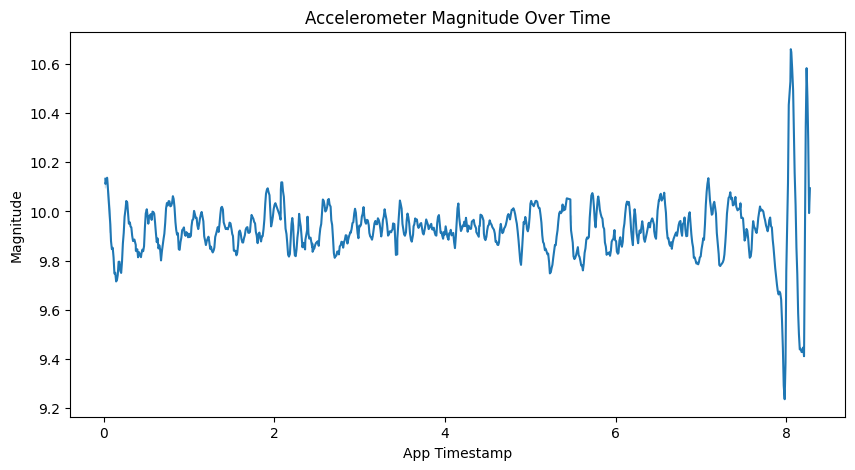

In [31]:
# Plot accelerometer magnitude over time
plt.figure(figsize=(10,5))
sns.lineplot(data=acc_df, x='app_ts', y='magnitude')
plt.title("Accelerometer Magnitude Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Magnitude")
plt.show()


<b>3. Gyroscope Analysis</b>

In [32]:
# Compute total rotation magnitude
gyro_df['rotation'] = (gyro_df['x']**2 + gyro_df['y']**2 + gyro_df['z']**2)**0.5
print(gyro_df['rotation'])

0      0.133071
1      0.100894
2      0.116714
3      0.187114
4      0.259167
         ...   
831    0.455397
832    0.698382
833    0.826304
834    0.649141
835    0.340236
Name: rotation, Length: 836, dtype: float64


In [33]:
# Basic statistics
print("Gyroscope Statistics:")
print(gyro_df['rotation'].describe())


Gyroscope Statistics:
count    836.000000
mean       0.071009
std        0.097663
min        0.003429
25%        0.024767
50%        0.038938
75%        0.065920
max        0.826304
Name: rotation, dtype: float64


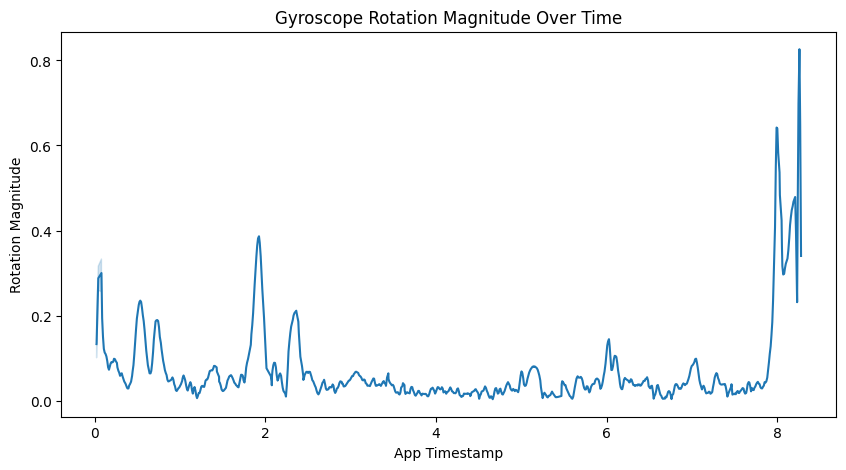

In [34]:
# Plot rotation over time
plt.figure(figsize=(10,5))
sns.lineplot(data=gyro_df, x='app_ts', y='rotation')
plt.title("Gyroscope Rotation Magnitude Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Rotation Magnitude")
plt.show()

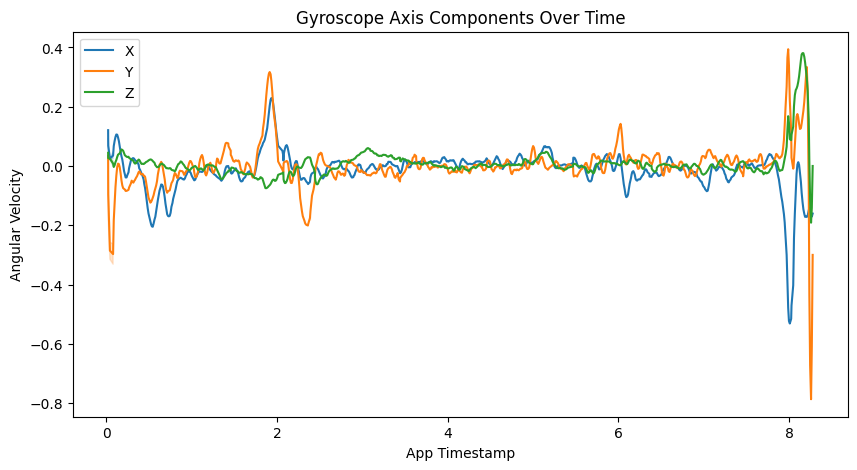

In [35]:
# Plot individual axis components
plt.figure(figsize=(10,5))
sns.lineplot(data=gyro_df, x='app_ts', y='x', label='X')
sns.lineplot(data=gyro_df, x='app_ts', y='y', label='Y')
sns.lineplot(data=gyro_df, x='app_ts', y='z', label='Z')
plt.title("Gyroscope Axis Components Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Angular Velocity")
plt.legend()
plt.show()

<b>4. Light Sensor Analysis<b>

In [36]:
# Basic statistics
print("Light Sensor Statistics:")
print(light_df['light'].describe())

Light Sensor Statistics:
count    24.000000
mean      0.416667
std       0.503610
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       1.000000
Name: light, dtype: float64


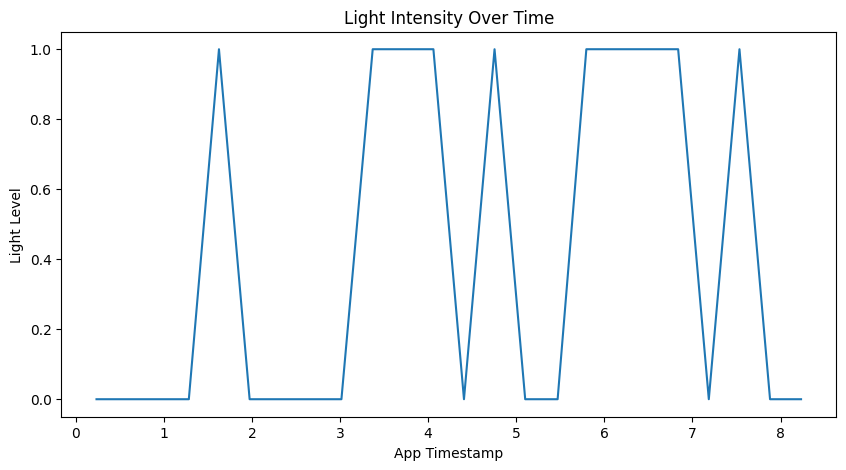

In [37]:
# Plot light intensity over time
plt.figure(figsize=(10,5))
sns.lineplot(data=light_df, x='app_ts', y='light')
plt.title("Light Intensity Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Light Level")
plt.show()

In [38]:
# Detect light changes or anomalies
light_df['change'] = light_df['light'].diff()

threshold = 1  # adjust as needed
anomalies = light_df[abs(light_df['change']) > threshold]

print(f"Detected {len(anomalies)} sudden light changes:")
print(anomalies[['app_ts','light','change']])



Detected 0 sudden light changes:
Empty DataFrame
Columns: [app_ts, light, change]
Index: []


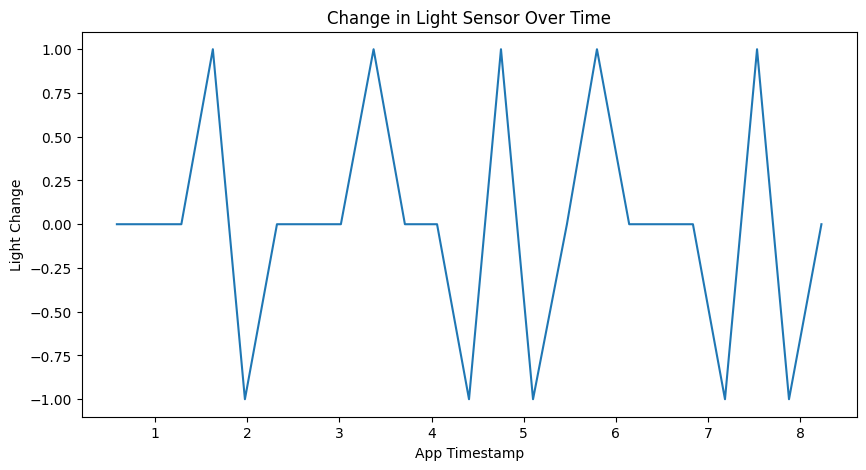

In [39]:
plt.figure(figsize=(10,5))
sns.lineplot(data=light_df, x='app_ts', y='change')
plt.title("Change in Light Sensor Over Time")
plt.xlabel("App Timestamp")
plt.ylabel("Light Change")
plt.show()


<b>5. Magnetometer Sensor Analysis<b>

In [44]:


# Calculate magnetic field magnitude
magn_df['mag_field'] = (magn_df['x']**2 + magn_df['y']**2 + magn_df['z']**2)**0.5

# Display statistical summary
print("Magnetometer Sensor Statistics:")
print(magn_df['mag_field'].describe())




Magnetometer Sensor Statistics:
count    836.000000
mean      44.110264
std        0.293488
min       43.199257
25%       43.902624
50%       44.111608
75%       44.302703
max       44.982809
Name: mag_field, dtype: float64


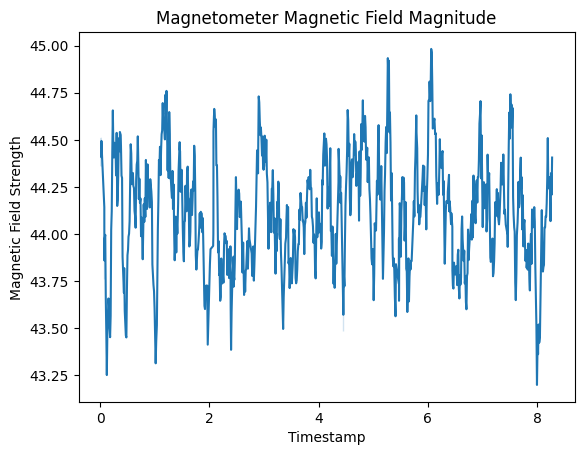

In [43]:
# Plot the magnetic field magnitude over time
sns.lineplot(data=magn_df, x='app_ts', y='mag_field').set(title="Magnetometer Magnetic Field Magnitude")
plt.xlabel("Timestamp")
plt.ylabel("Magnetic Field Strength")
plt.show()